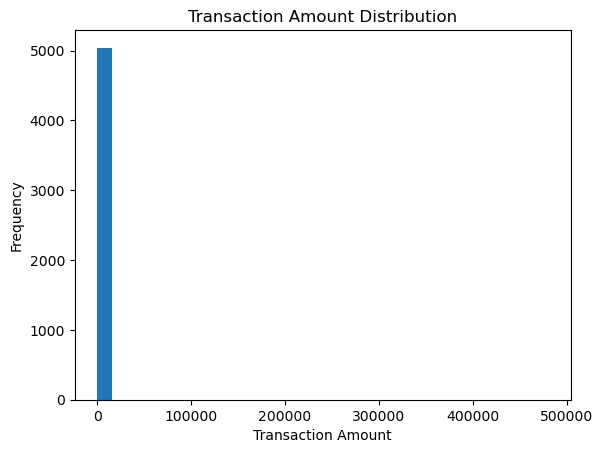

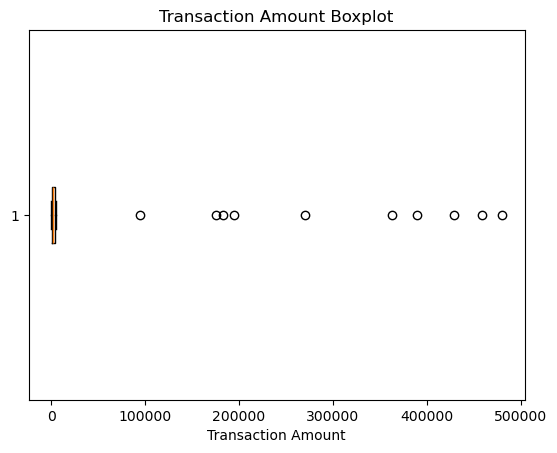

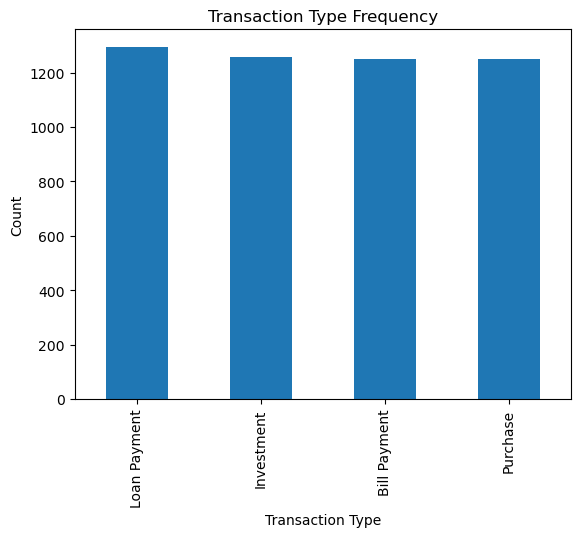

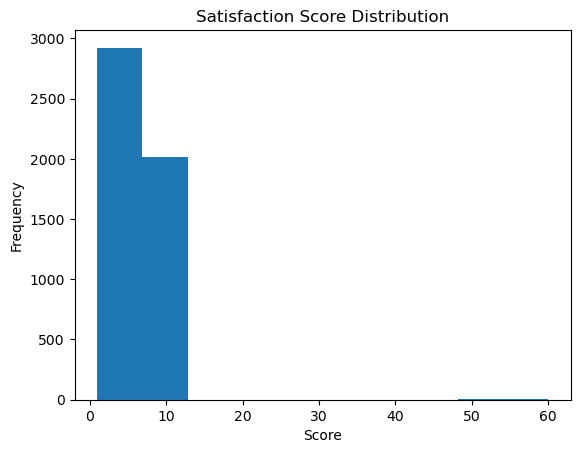

       Transaction_ID  Customer_ID               Transaction_Date  \
count     5050.000000  5050.000000                           5050   
mean      2498.927129   504.692871  2023-04-15 01:55:37.663366144   
min          1.000000     1.000000            2023-01-01 00:00:00   
25%       1250.250000   251.250000            2023-02-22 01:15:00   
50%       2500.500000   509.000000            2023-04-15 03:30:00   
75%       3745.750000   764.000000            2023-06-06 00:45:00   
max       5000.000000  1000.000000            2023-07-28 07:00:00   
std       1443.059092   291.593793                            NaN   

       Transaction_Amount  
count         5050.000000  
mean          3082.613069  
min             10.000000  
25%           1257.000000  
50%           2483.000000  
75%           3680.750000  
max         480300.000000  
std          14671.267809  


In [1]:
# --- IMPORT LIBRARIES ---
import pandas as pd
import matplotlib.pyplot as plt

# --- LOAD DATA ---
transactions_df = pd.read_csv('Transaction_Data.csv')
customer_df = pd.read_csv('Customer_Feedback_Data.csv')

# --- CLEAN (ensure consistency with your preprocessing) ---
transactions_df['Transaction_Amount'] = transactions_df['Transaction_Amount'].fillna(
    transactions_df['Transaction_Amount'].median()
)

# Convert date
transactions_df['Transaction_Date'] = pd.to_datetime(transactions_df['Transaction_Date'])

# --- 1. HISTOGRAM ---
plt.figure()
plt.hist(transactions_df['Transaction_Amount'], bins=30)
plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.savefig('transaction_histogram.png')
plt.show()

# --- 2. BOXPLOT ---
plt.figure()
plt.boxplot(transactions_df['Transaction_Amount'], vert=False)
plt.title('Transaction Amount Boxplot')
plt.xlabel('Transaction Amount')
plt.savefig('transaction_boxplot.png')
plt.show()

# --- 3. TRANSACTION TYPE BAR CHART ---
plt.figure()
transactions_df['Transaction_Type'].value_counts().plot(kind='bar')
plt.title('Transaction Type Frequency')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.savefig('transaction_type_bar.png')
plt.show()

# --- 4. SATISFACTION SCORE HISTOGRAM ---
plt.figure()
plt.hist(customer_df['Satisfaction_Score'], bins=10)
plt.title('Satisfaction Score Distribution')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.savefig('satisfaction_histogram.png')
plt.show()

# --- 5. DESCRIPTIVE TABLE ---
desc_stats = transactions_df.describe()
print(desc_stats)

# Save table
desc_stats.to_csv('descriptive_stats.csv')
